In [5]:
import tensorflow as tf

data_dir = "/content/drive/MyDrive/Colab Notebooks/Licenta/lfw"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 3073 files belonging to 63 classes.
Using 2459 files for training.
Found 3073 files belonging to 63 classes.
Using 614 files for validation.


### Dataset Exploration
Let's visualize the first 9 images from the training set to ensure the labels and images are loaded correctly.

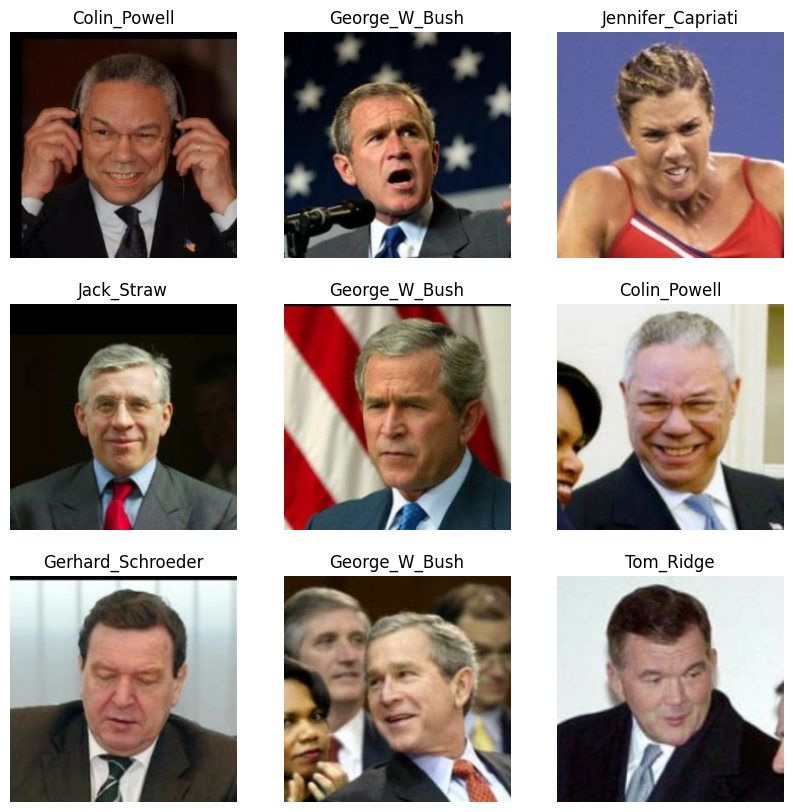

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Now, let's check the shape of the image batches and the total number of classes available.

In [7]:
for image_batch, labels_batch in train_ds:
  print(f"Image batch shape: {image_batch.shape}")
  print(f"Label batch shape: {labels_batch.shape}")
  break

print(f"Total classes: {len(class_names)}")

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Total classes: 63


### Focused Class Distribution
Since there are many classes, let's look at the top 20 to get a clearer view of the most frequent subjects.

In [9]:
import pandas as pd
import numpy as np

# Create a DataFrame for easier manipulation
df_counts = pd.DataFrame({
    'Person': class_names,
    'Count': np.bincount(all_labels)
})

# Sort and take the top 20
df_top20 = df_counts.sort_values(by='Count', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top20, x='Count', y='Person', palette='viridis', hue='Person', legend=False)
plt.title('Top 20 Most Frequent Individuals in Dataset')
plt.xlabel('Number of Images')
plt.ylabel('Name')
plt.show()

print(f"Minimum images per class: {df_counts['Count'].min()}")
print(f"Maximum images per class: {df_counts['Count'].max()}")
print(f"Average images per class: {df_counts['Count'].mean():.2f}")

NameError: name 'all_labels' is not defined

### Outlier Analysis
Let's visualize the statistical distribution of images per class to identify outliers using a boxplot and list the most extreme cases.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate statistics
stats = df_counts['Count'].describe()
print("Frequency Statistics:")
print(stats)

# Create a boxplot to see outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_counts['Count'], color='skyblue')
plt.title('Distribution of Images per Class (Identifying Outliers)')
plt.xlabel('Number of Images')
plt.show()

# Identify high-frequency outliers (using IQR method)
Q1 = stats['25%']
Q3 = stats['75%']
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

high_outliers = df_counts[df_counts['Count'] > upper_bound].sort_values(by='Count', ascending=False)
low_outliers = df_counts[df_counts['Count'] < 2] # Classes with only 1 image

print(f"\nUpper bound for outliers: {upper_bound}")
print(f"Number of high-frequency outliers: {len(high_outliers)}")
display(high_outliers.head(10))

print(f"\nNumber of classes with only 1 image: {len(low_outliers)}")

### Single Image Classes
Displaying the specific individuals who only have one image in this dataset.

In [ ]:

low_outliers = df_counts[df_counts['Count'] == 1]
display(low_outliers)

### Removing Low-Frequency Class
We are removing 'Hamid_Karzai' because having only one image prevents proper training and validation for that specific class.

In [ ]:
target_class = 'Hamid_Karzai'

if target_class in class_names:
    target_label = class_names.index(target_class)

    # Unbatch, filter, then re-batch to avoid the predicate vector error
    def filter_class(image, label):
        return label != target_label

    train_ds = train_ds.unbatch().filter(filter_class).batch(32)
    val_ds = val_ds.unbatch().filter(filter_class).batch(32)

    print(f"Successfully filtered out {target_class} (Label index: {target_label})")
else:
    print(f"{target_class} is already not present in class_names.")

In [ ]:
# Verification: Check if any samples of the deleted class remain in a sample batch
found = False
for _, labels in train_ds.take(20): # Check more batches for certainty
    if target_label in labels.numpy():
        found = True
        break

if not found:
    print(f"Verification successful: {target_class} not found in sample batches.")
else:
    print(f"Warning: {target_class} still detected in dataset.")